# Model system - NMF components

In [1]:
%matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt
import hyperspy.api as hs
import pyxem as pxm
from IPython.display import display
from ipywidgets import Dropdown, interactive, Layout, FloatSlider

plt.rcParams.update({'font.size': 10})
plt.rcParams['figure.dpi'] = 150

C:\Users\tinabe\Documents\mini\envs\pm-paper2\Lib\site-packages\hyperspy\misc\utils.py:72: VisibleDeprecationWarning: `_get_block_pattern` has moved to `hyperspy.misc.dask_utils`. It is for internal use only and may be removed in the future.
  warnings.warn(


In [2]:
folder_data = '.\\data\\'

loadings = []
factors = []

for root, dirs, files in os.walk(folder_data):
    for file in files:
        if file.startswith('nmf_') and file.endswith('_loadings.hspy'):
            loading = hs.load(folder_data+file)
            loadings.append(loading)
        elif file.startswith('nmf_') and file.endswith('_factors.hspy'):
            factor = hs.load(folder_data+file)
            factors.append(factor)

In [3]:
ncs = np.arange(1, 21, 1)

loadings_i = np.zeros_like(loadings[-1].data)
factors_i = np.zeros_like(factors[-1].data)

i = 4
for ii in np.arange(i+1):
    loadings_i[ii] = loadings[i].inav[ii].data
    factors_i[ii] = factors[i].inav[ii].data

Dropdown(description='Number of components:', index=4, layout=Layout(width='230px'), options=(np.int64(1), np.…

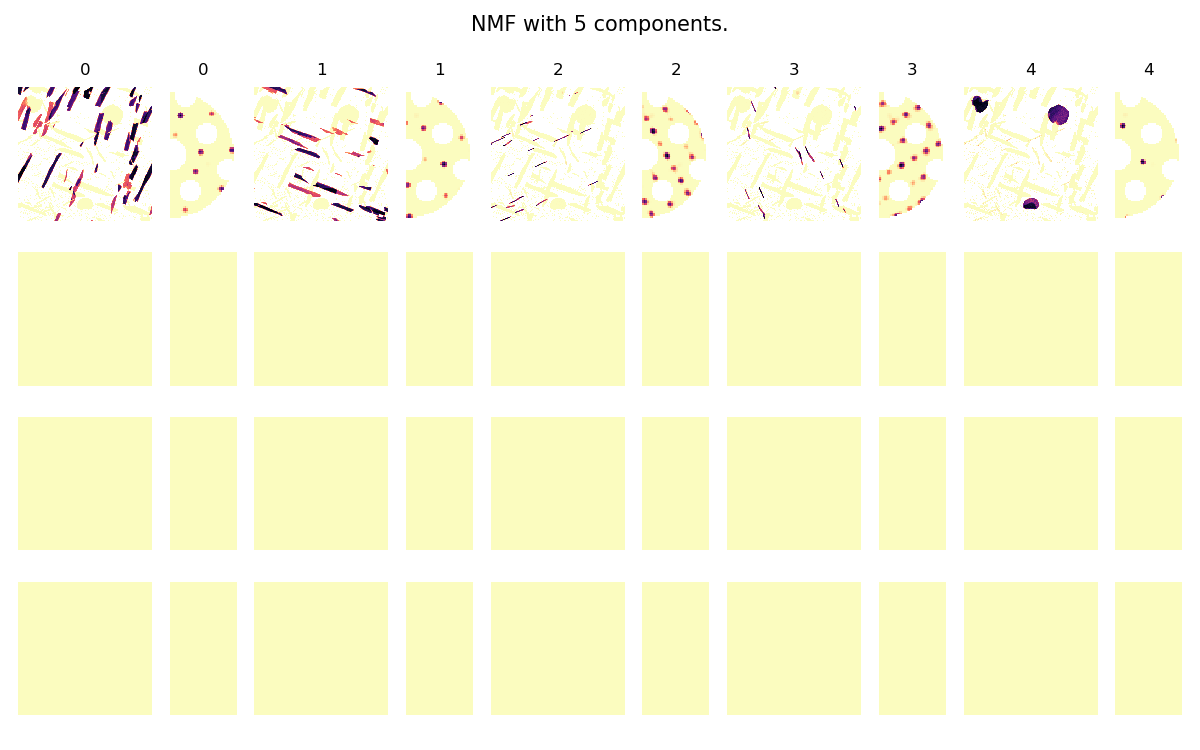

In [4]:
fig = plt.figure(layout='tight', figsize=(8, 5))

cmap='magma_r'
axs0, axs1, axs2, axs3 = fig.subplots(4, 10, height_ratios=[1]*4, width_ratios=[1, 0.5]*5)

lis = np.arange(0, 10, 2)
fis = np.arange(1, 11, 2)

l_axs = []
f_axs = []
for li, l, fi, f in zip(lis, loadings_i[:5], fis, factors_i[:5]):
    axs0[li].axis('off')
    l_axs.append(axs0[li].imshow(l, cmap=cmap, interpolation='none'))
    axs0[fi].axis('off')
    f_axs.append(axs0[fi].imshow(f, cmap=cmap, interpolation='none'))
for li, l, fi, f in zip(lis, loadings_i[5:10], fis, factors_i[5:10]):
    axs1[li].axis('off')
    l_axs.append(axs1[li].imshow(l, cmap=cmap, interpolation='none'))
    axs1[fi].axis('off')
    f_axs.append(axs1[fi].imshow(f, cmap=cmap, interpolation='none'))
for li, l, fi, f in zip(lis, loadings_i[10:15], fis, factors_i[10:15]):
    axs2[li].axis('off')
    l_axs.append(axs2[li].imshow(l, cmap=cmap, interpolation='none'))
    axs2[fi].axis('off')
    f_axs.append(axs2[fi].imshow(f, cmap=cmap, interpolation='none'))
for li, l, fi, f in zip(lis, loadings_i[15:20], fis, factors_i[15:20]):
    axs3[li].axis('off')
    l_axs.append(axs3[li].imshow(l, cmap=cmap, interpolation='none'))
    axs3[fi].axis('off')
    f_axs.append(axs3[fi].imshow(f, cmap=cmap, interpolation='none'))
for ii, ax in zip(np.repeat(np.arange(i+1), 2), axs0):
    ax.set_title(str(ii), fontsize=8)

fig.canvas.resizable = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.toolbar_visible = True
fig.canvas.toolbar_position = 'top'

fig.suptitle('NMF with ' + str(i+1) + ' components.', fontsize=12)

def update_plot(change):
    i = change['new']-1
    
    loadings_i = np.zeros_like(loadings[-1].data)
    factors_i = np.zeros_like(factors[-1].data)
    for ii in np.arange(i+1):
        loadings_i[ii] = loadings[i].inav[ii].data
        factors_i[ii] = factors[i].inav[ii].data

    for l_ax, l, f_ax, f in zip(l_axs, loadings_i, f_axs, factors_i):
        l_ax.set_data(l)
        l_ax.set_clim([np.min(l[~np.isnan(l)]), np.max(l[~np.isnan(l)])])
        f_ax.set_data(f)
        f_ax.set_clim([np.min(f[~np.isnan(f)]), np.max(f[~np.isnan(f)])])  

    titles = ['']*40
    for ii, t in zip(np.arange((i+1)*2), np.repeat(np.arange(i+1), 2)):
        titles[ii] = str(t)

    for ax0, t in zip(axs0, titles[:10]):
        ax0.set_title(t)
    for ax1, t in zip(axs1, titles[10:20]):
        ax1.set_title(t)    
    for ax2, t in zip(axs2, titles[20:30]):
        ax2.set_title(t)    
    for ax3, t in zip(axs3, titles[30:40]):
        ax3.set_title(t)
        
    fig.suptitle('NMF with ' + str(i+1) + ' components.', fontsize=12)
    
    fig.canvas.draw_idle()
    return None

nc_widget = Dropdown(options=ncs, index=i, description='Number of components:', 
                           layout=Layout(width='230px'), style={'description_width': '150px'}, disabled=False)
nc_widget.observe(update_plot, names='value')
display(nc_widget)